
===== SEQ LENGTH = 100 =====
Step   0: 0.0000000000
Step   1: 0.0000000000
Step   2: 0.0000000000
Step   3: 0.0000000000
Step   4: 0.0000000000
Step   5: 0.0000000000
Step   6: 0.0000000000
Step   7: 0.0000000000
Step   8: 0.0000000000
Step   9: 0.0000000000
Step  10: 0.0000000000
Step  11: 0.0000000000
Step  12: 0.0000000000
Step  13: 0.0000000000
Step  14: 0.0000000000
Step  15: 0.0000000000
Step  16: 0.0000000000
Step  17: 0.0000000000
Step  18: 0.0000000000
Step  19: 0.0000000000
Step  20: 0.0000000000
Step  21: 0.0000000000
Step  22: 0.0000000000
Step  23: 0.0000000000
Step  24: 0.0000000000
Step  25: 0.0000000000
Step  26: 0.0000000000
Step  27: 0.0000000000
Step  28: 0.0000000000
Step  29: 0.0000000000
Step  30: 0.0000000000
Step  31: 0.0000000000
Step  32: 0.0000000000
Step  33: 0.0000000000
Step  34: 0.0000000000
Step  35: 0.0000000000
Step  36: 0.0000000000
Step  37: 0.0000000000
Step  38: 0.0000000000
Step  39: 0.0000000000
Step  40: 0.0000000000
Step  41: 0.0000000000
Step

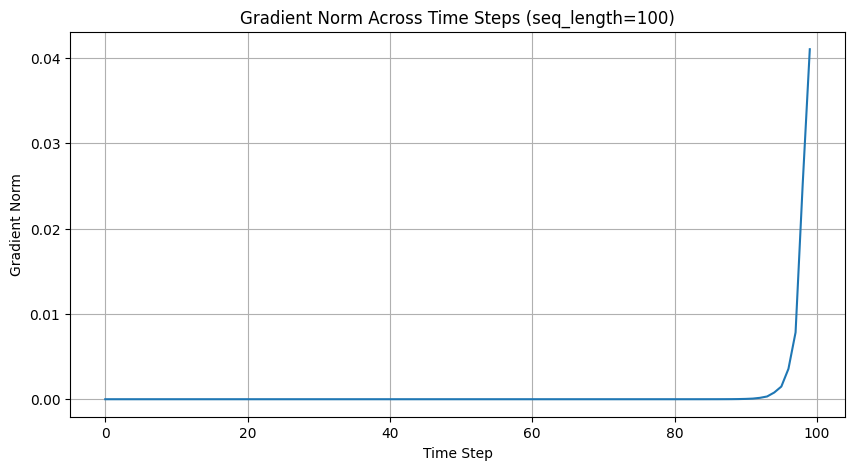


===== SEQ LENGTH = 10 =====
Step   0: 0.0004807053
Step   1: 0.0007888647
Step   2: 0.0012541870
Step   3: 0.0018848546
Step   4: 0.0027671487
Step   5: 0.0040868833
Step   6: 0.0060265623
Step   7: 0.0082324632
Step   8: 0.0121800825
Step   9: 0.0305881146


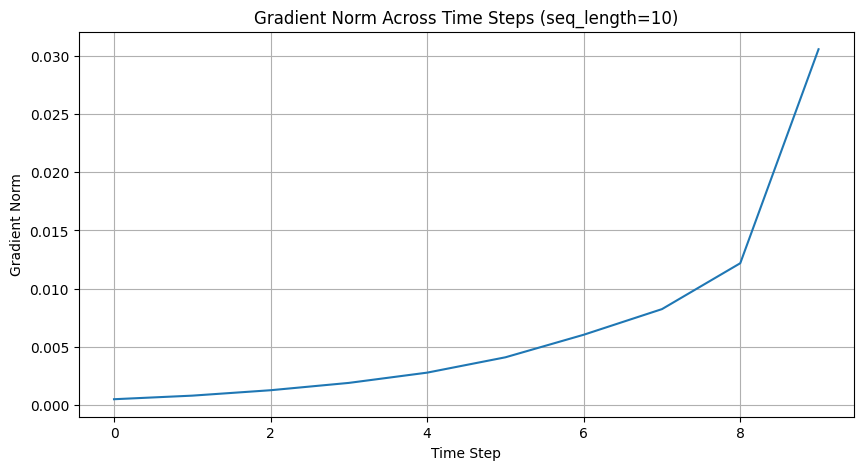

In [1]:

# 1. IMPORT
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)


# 2. TẠO DỮ LIỆU SIN

data = np.sin(np.linspace(0, 50, 500))

# 3. HÀM TẠO DATASET

def create_dataset(data, seq_length):

    X = []
    y = []

    for i in range(len(data) - seq_length):

        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])

    X = np.array(X)
    y = np.array(y)

    return X, y


# 4. CUSTOM RNN ĐỂ LƯU HIDDEN STATE

class SimpleRNN(nn.Module):

    def __init__(self, input_size=1, hidden_size=8):

        super(SimpleRNN, self).__init__()

        self.hidden_size = hidden_size

        self.i2h = nn.Linear(input_size + hidden_size, hidden_size)
        self.h2o = nn.Linear(hidden_size, 1)

        self.hidden_states = []

    def forward(self, x):

        batch_size = x.size(0)

        h = torch.zeros(batch_size, self.hidden_size)

        self.hidden_states = []

        seq_len = x.size(1)

        for t in range(seq_len):

            xt = x[:, t, :]

            combined = torch.cat((xt, h), dim=1)

            h = torch.tanh(self.i2h(combined))

            # retain gradient để xem grad từng timestep
            h.retain_grad()

            self.hidden_states.append(h)

        out = self.h2o(h)

        return out


# ==========================================
# 5. HÀM THÍ NGHIỆM
# ==========================================
def run_experiment(seq_length):

    print(f"\n===== SEQ LENGTH = {seq_length} =====")

    # tạo dataset
    X, y = create_dataset(data, seq_length)

    X_tensor = torch.FloatTensor(X).unsqueeze(-1)
    y_tensor = torch.FloatTensor(y).unsqueeze(-1)

    # model
    model = SimpleRNN(hidden_size=8)

    criterion = nn.MSELoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    # forward
    output = model(X_tensor)

    loss = criterion(output, y_tensor)

    # backward
    optimizer.zero_grad()

    loss.backward()

    # ======================================
    # LẤY GRADIENT NORM THEO TIMESTEP
    # ======================================
    grad_norms = []

    for h in model.hidden_states:

        grad_norm = h.grad.norm().item()

        grad_norms.append(grad_norm)

    # ======================================
    # IN KẾT QUẢ
    # ======================================
    for i, g in enumerate(grad_norms):

        print(f"Step {i:3d}: {g:.10f}")

    # ======================================
    # VẼ BIỂU ĐỒ

    plt.figure(figsize=(10,5))

    plt.plot(grad_norms)

    plt.title(f"Gradient Norm Across Time Steps (seq_length={seq_length})")

    plt.xlabel("Time Step")

    plt.ylabel("Gradient Norm")

    plt.grid(True)

    plt.show()



# 6. THÍ NGHIỆM
# chuỗi dài
run_experiment(seq_length=100)

# chuỗi ngắn
run_experiment(seq_length=10)